<a href="https://colab.research.google.com/github/Latifmmhd/Augmentasi-Data-Indonesia-Tweet/blob/main/ft_with_peft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip Emotion-classification-with-PEFT_Augmented.zip

Archive:  Emotion-classification-with-PEFT_Augmented.zip
   creating: Emotion-classification-with-PEFT_Augmented/
   creating: Emotion-classification-with-PEFT_Augmented/.git/
  inflating: Emotion-classification-with-PEFT_Augmented/.git/config  
  inflating: Emotion-classification-with-PEFT_Augmented/.git/description  
  inflating: Emotion-classification-with-PEFT_Augmented/.git/HEAD  
   creating: Emotion-classification-with-PEFT_Augmented/.git/hooks/
  inflating: Emotion-classification-with-PEFT_Augmented/.git/hooks/applypatch-msg.sample  
  inflating: Emotion-classification-with-PEFT_Augmented/.git/hooks/commit-msg.sample  
  inflating: Emotion-classification-with-PEFT_Augmented/.git/hooks/fsmonitor-watchman.sample  
  inflating: Emotion-classification-with-PEFT_Augmented/.git/hooks/post-update.sample  
  inflating: Emotion-classification-with-PEFT_Augmented/.git/hooks/pre-applypatch.sample  
  inflating: Emotion-classification-with-PEFT_Augmented/.git/hooks/pre-commit.sample  
  in

In [2]:
%cd Emotion-classification-with-PEFT_Augmented

/content/Emotion-classification-with-PEFT_Augmented


In [3]:
!pip install -r requirements.txt

  Cloning https://github.com/huggingface/peft (to revision cf04d0353f0343cbf66627228c4495f51669af34) to /tmp/pip-install-q24zmy1n/peft_0ce92aadab93408d9742668c8c0aa767
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft /tmp/pip-install-q24zmy1n/peft_0ce92aadab93408d9742668c8c0aa767
  Running command git rev-parse -q --verify 'sha^cf04d0353f0343cbf66627228c4495f51669af34'
  Running command git fetch -q https://github.com/huggingface/peft cf04d0353f0343cbf66627228c4495f51669af34
  Running command git checkout -q cf04d0353f0343cbf66627228c4495f51669af34
  Resolved https://github.com/huggingface/peft to commit cf04d0353f0343cbf66627228c4495f51669af34
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5

In [4]:
import pandas as pd
import numpy as np
import os
import torch
import time
import json

from peft import LoraConfig, LoraModel, get_peft_model, TaskType
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
use_cuda = torch.cuda.is_available()

In [5]:
df = pd.read_csv('dataset/all_data.csv')
train_data = pd.read_csv('dataset/train.csv')
val_data = pd.read_csv('dataset/val.csv')
test_data = pd.read_csv('dataset/test.csv')

# Length train, val, and test
print("Train: ",len(train_data))
print("Val: ",len(val_data))
print("Test: ",len(test_data))

Train:  8820
Val:  1890
Test:  1890


In [6]:
tags = np.unique(df['label'])
num_labels = len(tags)
max_length = 128
label2id = {t: i for i, t in enumerate(tags)}
id2label = {i: t for i, t in enumerate(tags)}

In [7]:
label2id

{'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'neutral': 4, 'sad': 5}

In [8]:
def model_init(model_name):
    global tokenizer
    global data_collator
    global tr_model

    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, model_max_length=128)

    # Configure LoRA
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8, # Rank of the low-rank matrices
        lora_alpha=32,
        lora_dropout=0.1
    )

    # Wrap the base model with the LoRA configuration
    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()

    return model, tokenizer


def tokenize_function(examples):
    # process the input sequence
    tokenized_input = tokenizer(examples["tweet"],
                                truncation=True,
                                padding='max_length',
                                max_length=max_length)
    # process the labels
    tokenized_input['label'] = [label2id[lb] for lb in examples['label']]

    return tokenized_input


def preprocessing():
    X_train = Dataset.from_pandas(train_data)
    X_val = Dataset.from_pandas(val_data)
    X_test = Dataset.from_pandas(test_data)

    tokenized_train_data = X_train.map(tokenize_function, batched=True)
    tokenized_val_data = X_val.map(tokenize_function, batched=True)
    tokenized_test_data = X_test.map(tokenize_function, batched=True)

    return tokenized_train_data, tokenized_val_data, tokenized_test_data


def compute_metrics(p):
    pred, labels = p
    pred = np.argmax(pred, axis=1)

    true_labels = [tags[l] for l in labels]
    true_predictions = [tags[pr] for pr in pred]

    report = classification_report(true_labels, true_predictions, digits=4)
    acc = accuracy_score(y_true=true_labels, y_pred=true_predictions)
    rec = recall_score(y_true=true_labels, y_pred=true_predictions, average="macro")
    prec = precision_score(y_true=true_labels, y_pred=true_predictions, average="macro")
    f1 = f1_score(y_true=true_labels, y_pred=true_predictions, average="macro", zero_division=1.0)

    print("Classification Report:\n{}".format(report))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [9]:
# to generate the confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def generate_confusion_matrix(true_labels, pred_labels, num_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    labels = [id2label[i] for i in range(num_labels)]
    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.5)
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.yticks(rotation=0)
    plt.show()

In [10]:
def train_model(model_name, output_dir, learning_rate, train_batch_size, eval_batch_size, num_epochs, weight_decay):

    model, tokenizer = model_init(model_name)
    train_tokenized, val_tokenized, test_tokenized = preprocessing()

    training_args = TrainingArguments(
        output_dir=output_dir,
        logging_strategy="epoch",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit = 1,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        #push_to_hub=True, # to push to hub during the training
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    trainer.save_model(output_dir)
    #trainer.push_to_hub(commit_message="Training complete")

    # Get the evaluation results
    trainer.eval_dataset=test_tokenized
    evaluation_results = trainer.evaluate()
    print(evaluation_results)

    # make prediction on the test set
    predictions = trainer.predict(test_tokenized)
    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = test_tokenized["label"]

    # Generate confusion matrix
    generate_confusion_matrix(true_labels, pred_labels, num_labels)

    return trainer

In [11]:
def show_log_history(trainer):
    log_history = pd.DataFrame(trainer.state.log_history)
    log_history = log_history.fillna(0)
    log_history = log_history.groupby(["epoch"]).sum()

    log_history[["loss", "eval_loss"]].plot()
    plt.show()

In [12]:
def main(model_name, output_dir, best_params):
    start = time.time()
     # load json file containing best params
    best_params = best_params

    with open(best_params, 'r') as js:
        data = json.load(js)

    print(data)

    # define best params
    num_train_epochs = data['num_train_epochs']
    learning_rate = data['learning_rate']
    train_batch_size = data['per_device_train_batch_size']
    eval_batch_size = data['per_device_eval_batch_size']
    weight_decay = data['weight_decay']

    # training
    tr_model = train_model(model_name=model_name,
                           output_dir=output_dir,
                           learning_rate=learning_rate,
                           train_batch_size=train_batch_size,
                           eval_batch_size=eval_batch_size,
                           num_epochs=num_train_epochs,
                           weight_decay=weight_decay)

    print('Training finished!')

    show_log_history(tr_model)


    end = time.time()
    exec_time = (end - start) / 60
    print(f'Total time: {exec_time} minutes')

{'num_train_epochs': 10, 'learning_rate': 0.0003, 'per_device_train_batch_size': 16, 'per_device_eval_batch_size': 16, 'weight_decay': 0.017612687697176877}


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 21523190 (21523190-universitas-islam-indonesia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.875700,0.676557,0.773545,0.775195,0.778540,0.769244
2,0.580700,0.620166,0.796296,0.798318,0.799691,0.794761
3,0.501900,0.612394,0.793122,0.794369,0.796211,0.791939
4,0.445000,0.590032,0.807937,0.809271,0.810957,0.808195
5,0.390100,0.624345,0.806878,0.806974,0.809848,0.806001
6,0.347800,0.643797,0.807407,0.806691,0.810459,0.806533
7,0.303600,0.653137,0.812698,0.812482,0.815546,0.812543
8,0.274700,0.686385,0.813757,0.812776,0.816927,0.812933
9,0.256800,0.711257,0.806349,0.805650,0.809730,0.804815
10,0.232100,0.698924,0.809524,0.808990,0.812429,0.808928


Classification Report:
              precision    recall  f1-score   support

       anger     0.7395    0.8627    0.7964       306
        fear     0.7570    0.8710    0.8100       279
         joy     0.7974    0.7372    0.7661       331
        love     0.7513    0.9153    0.8253       307
     neutral     0.7742    0.5122    0.6165       328
         sad     0.8317    0.7729    0.8012       339

    accuracy                         0.7735      1890
   macro avg     0.7752    0.7785    0.7692      1890
weighted avg     0.7767    0.7735    0.7674      1890

Classification Report:
              precision    recall  f1-score   support

       anger     0.7890    0.8431    0.8152       306
        fear     0.8282    0.8638    0.8456       279
         joy     0.8344    0.7613    0.7962       331
        love     0.7454    0.9153    0.8216       307
     neutral     0.7895    0.5945    0.6783       328
         sad     0.8035    0.8201    0.8117       339

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       anger     0.8285    0.8101    0.8192       316
        fear     0.8584    0.8559    0.8571       333
         joy     0.8056    0.8182    0.8118       319
        love     0.7971    0.9003    0.8456       301
     neutral     0.7240    0.6925    0.7079       322
         sad     0.8087    0.7492    0.7778       299

    accuracy                         0.8042      1890
   macro avg     0.8037    0.8044    0.8032      1890
weighted avg     0.8040    0.8042    0.8033      1890

{'eval_loss': 0.5876018404960632, 'eval_accuracy': 0.8042328042328042, 'eval_precision': 0.803702885396632, 'eval_recall': 0.8043678242798951, 'eval_f1': 0.8032384267759068, 'eval_runtime': 3.8924, 'eval_samples_per_second': 485.558, 'eval_steps_per_second': 30.572, 'epoch': 10.0}
Classification Report:
              precision    recall  f1-score   support

       anger     0.8285    0.8101    0.8192       316
        fear     0.8

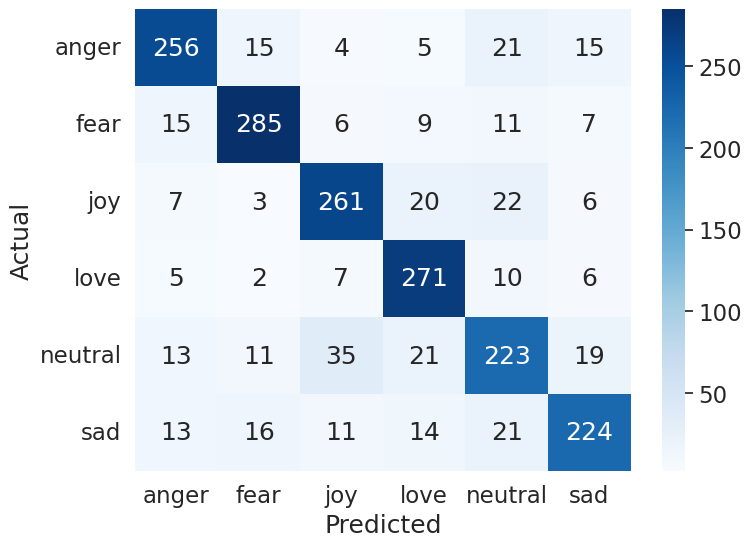

Training finished!


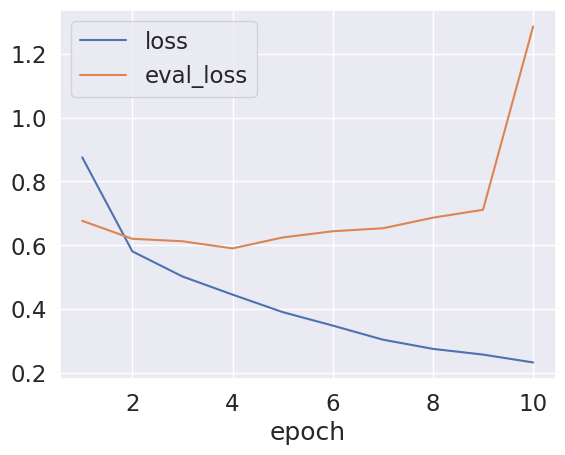

Total time: 7.861302638053894 minutes


In [13]:
#1 IndoBERTweet peft

main(
    model_name = 'indolem/indobertweet-base-uncased',
    output_dir = 'p-emotcls-indobertweet-base',
    best_params = 'best_params/p-indobertweet.json'
)

{'num_train_epochs': 8, 'learning_rate': 0.0001, 'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 16, 'weight_decay': 0.051746673667584155}


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.224800,0.811634,0.748148,0.756056,0.753989,0.742166
2,0.708000,0.703042,0.773016,0.774814,0.777255,0.768292
3,0.628400,0.640729,0.780423,0.780645,0.782750,0.779016
4,0.596100,0.622833,0.783069,0.786685,0.786411,0.784752
5,0.561200,0.614375,0.795238,0.795426,0.797584,0.794112
6,0.534800,0.599270,0.801058,0.800423,0.803016,0.801076
7,0.512700,0.605803,0.799471,0.799102,0.802811,0.797944
8,0.501000,0.602215,0.793651,0.792753,0.797262,0.792708


Classification Report:
              precision    recall  f1-score   support

       anger     0.6971    0.8497    0.7658       306
        fear     0.7627    0.8638    0.8101       279
         joy     0.7872    0.7039    0.7432       331
        love     0.6846    0.9121    0.7821       307
     neutral     0.7861    0.4482    0.5709       328
         sad     0.8188    0.7463    0.7809       339

    accuracy                         0.7481      1890
   macro avg     0.7561    0.7540    0.7422      1890
weighted avg     0.7578    0.7481    0.7399      1890

Classification Report:
              precision    recall  f1-score   support

       anger     0.7402    0.8660    0.7982       306
        fear     0.7799    0.8638    0.8197       279
         joy     0.7883    0.7311    0.7586       331
        love     0.7810    0.8827    0.8287       307
     neutral     0.7902    0.4939    0.6079       328
         sad     0.7692    0.8260    0.7966       339

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       anger     0.8602    0.7595    0.8067       316
        fear     0.8546    0.8649    0.8597       333
         joy     0.7865    0.8433    0.8139       319
        love     0.7994    0.8738    0.8349       301
     neutral     0.6926    0.6366    0.6634       322
         sad     0.7655    0.7860    0.7756       299

    accuracy                         0.7937      1890
   macro avg     0.7931    0.7940    0.7924      1890
weighted avg     0.7936    0.7937    0.7924      1890

{'eval_loss': 0.5864914059638977, 'eval_accuracy': 0.7936507936507936, 'eval_precision': 0.7931326909049264, 'eval_recall': 0.7939953361088466, 'eval_f1': 0.7923785167664846, 'eval_runtime': 10.7444, 'eval_samples_per_second': 175.906, 'eval_steps_per_second': 11.076, 'epoch': 8.0}
Classification Report:
              precision    recall  f1-score   support

       anger     0.8602    0.7595    0.8067       316
        fear     0.

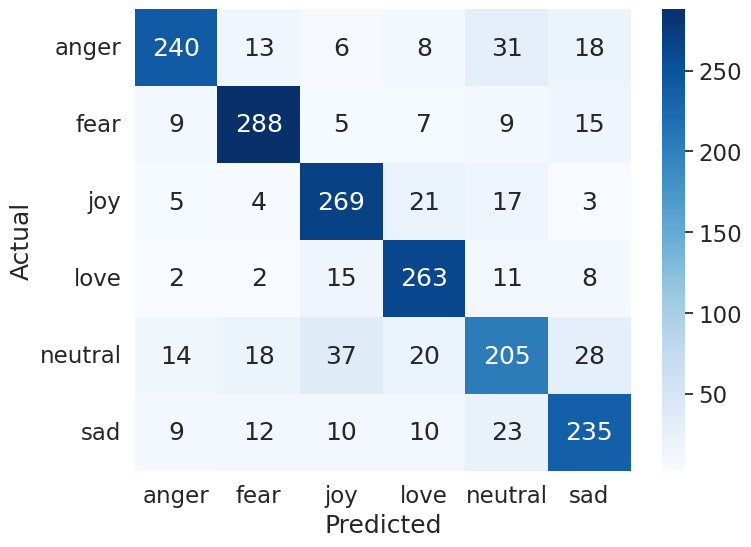

Training finished!


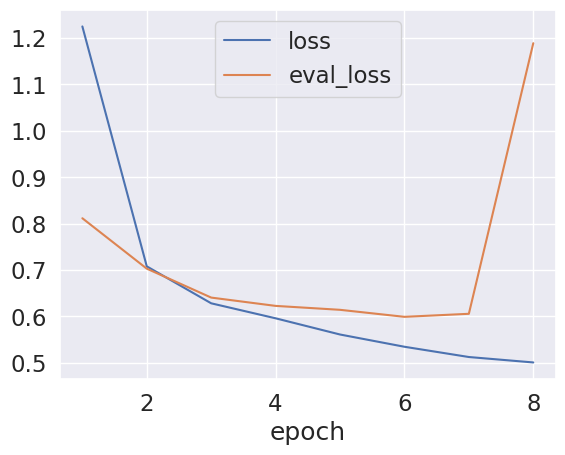

Total time: 15.100792586803436 minutes


In [14]:
#2 FacebookAI/xlm-roberta-large peft

main(
    model_name = 'FacebookAI/xlm-roberta-large',
    output_dir = 'p-emotcls-xlm-r-large',
    best_params = 'best_params/p-xlm-r-large.json'
)

{'num_train_epochs': 9, 'learning_rate': 0.0003, 'per_device_train_batch_size': 64, 'per_device_eval_batch_size': 64, 'weight_decay': 0.031010950841257247}


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.231700,0.907167,0.718519,0.741711,0.725126,0.706494
2,0.823500,0.801627,0.744974,0.752239,0.749600,0.739970
3,0.723600,0.769803,0.747619,0.753843,0.750812,0.743826
4,0.666600,0.684074,0.771429,0.770672,0.774185,0.770602
5,0.630200,0.703895,0.766667,0.767913,0.769305,0.763074
6,0.602000,0.667026,0.778836,0.778720,0.780988,0.777334
7,0.564100,0.670440,0.782011,0.782536,0.785662,0.780403
8,0.549800,0.683572,0.779365,0.779130,0.783770,0.776853
9,0.540800,0.669511,0.777249,0.776553,0.781078,0.775336


Classification Report:
              precision    recall  f1-score   support

       anger     0.6204    0.8333    0.7113       306
        fear     0.6761    0.8602    0.7571       279
         joy     0.7379    0.6888    0.7125       331
        love     0.7346    0.8925    0.8059       307
     neutral     0.8952    0.3384    0.4912       328
         sad     0.7862    0.7375    0.7610       339

    accuracy                         0.7185      1890
   macro avg     0.7417    0.7251    0.7065      1890
weighted avg     0.7452    0.7185    0.7043      1890

Classification Report:
              precision    recall  f1-score   support

       anger     0.7217    0.8137    0.7650       306
        fear     0.7741    0.8351    0.8034       279
         joy     0.8095    0.6677    0.7318       331
        love     0.6813    0.9121    0.7799       307
     neutral     0.7789    0.4726    0.5882       328
         sad     0.7479    0.7965    0.7714       339

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       anger     0.8079    0.7722    0.7896       316
        fear     0.8371    0.7868    0.8111       333
         joy     0.7672    0.8370    0.8006       319
        love     0.8250    0.8771    0.8502       301
     neutral     0.7724    0.5901    0.6690       322
         sad     0.6676    0.8060    0.7303       299

    accuracy                         0.7767      1890
   macro avg     0.7795    0.7782    0.7752      1890
weighted avg     0.7807    0.7767    0.7750      1890

{'eval_loss': 0.6498663425445557, 'eval_accuracy': 0.7767195767195767, 'eval_precision': 0.7795328088885601, 'eval_recall': 0.7781813119638761, 'eval_f1': 0.7751579807724358, 'eval_runtime': 3.2568, 'eval_samples_per_second': 580.333, 'eval_steps_per_second': 9.212, 'epoch': 9.0}
Classification Report:
              precision    recall  f1-score   support

       anger     0.8079    0.7722    0.7896       316
        fear     0.83

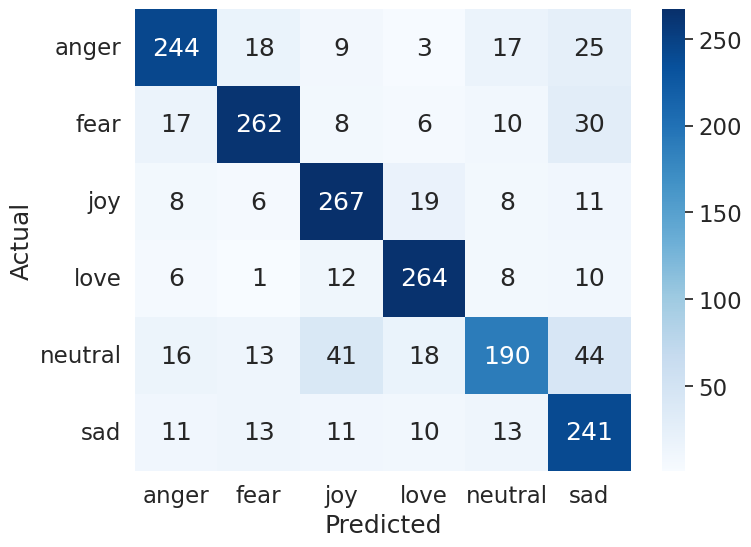

Training finished!


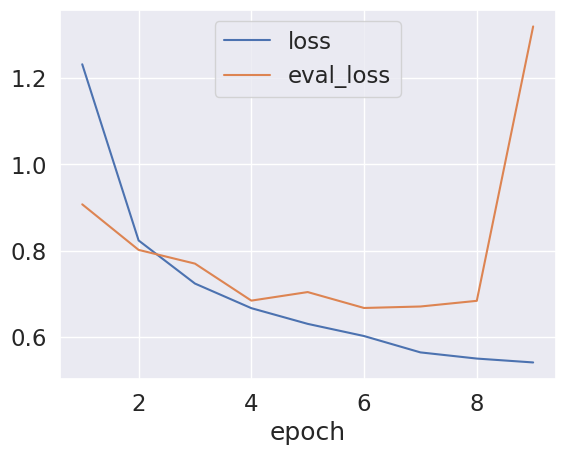

Total time: 5.450586485862732 minutes


In [15]:
#3 FacebookAI/xlm-roberta-base peft

main(
    model_name = 'FacebookAI/xlm-roberta-base',
    output_dir = 'p-emotcls-xlm-r-base',
    best_params = 'best_params/p-xlm-r-base.json'
)

{'num_train_epochs': 10, 'learning_rate': 5e-05, 'per_device_train_batch_size': 8, 'per_device_eval_batch_size': 16, 'weight_decay': 0.013382610498702853}


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.675100,1.431811,0.414815,0.427480,0.423755,0.388001
2,1.303800,1.196375,0.567196,0.571398,0.571028,0.563736
3,1.077900,1.083839,0.608466,0.600522,0.610620,0.595525
4,0.979700,1.024363,0.640212,0.641969,0.643905,0.635905
5,0.917000,1.004256,0.652381,0.656945,0.656880,0.647697
6,0.872300,0.978369,0.670899,0.670670,0.675120,0.666817
7,0.842100,0.951174,0.683069,0.682247,0.686407,0.679698
8,0.821300,0.960034,0.679365,0.679336,0.683231,0.674975
9,0.801300,0.956150,0.685185,0.686365,0.689273,0.680962
10,0.792200,0.949764,0.684656,0.684573,0.688789,0.680852


Classification Report:
              precision    recall  f1-score   support

       anger     0.3221    0.2810    0.3002       306
        fear     0.3487    0.5950    0.4397       279
         joy     0.4967    0.2296    0.3140       331
        love     0.4393    0.8013    0.5675       307
     neutral     0.4880    0.4970    0.4924       328
         sad     0.4700    0.1386    0.2141       339

    accuracy                         0.4148      1890
   macro avg     0.4275    0.4238    0.3880      1890
weighted avg     0.4310    0.4148    0.3846      1890

Classification Report:
              precision    recall  f1-score   support

       anger     0.3750    0.4118    0.3925       306
        fear     0.5068    0.6667    0.5759       279
         joy     0.6667    0.5801    0.6204       331
        love     0.6538    0.8306    0.7317       307
     neutral     0.5744    0.4238    0.4877       328
         sad     0.6517    0.5133    0.5743       339

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       anger     0.6424    0.6139    0.6278       316
        fear     0.7352    0.7838    0.7587       333
         joy     0.7704    0.7680    0.7692       319
        love     0.7225    0.8738    0.7910       301
     neutral     0.6786    0.5311    0.5958       322
         sad     0.6957    0.6957    0.6957       299

    accuracy                         0.7101      1890
   macro avg     0.7075    0.7110    0.7064      1890
weighted avg     0.7077    0.7101    0.7060      1890

{'eval_loss': 0.8866616487503052, 'eval_accuracy': 0.71005291005291, 'eval_precision': 0.7074644500250283, 'eval_recall': 0.7110325233574472, 'eval_f1': 0.7063719745877934, 'eval_runtime': 3.9479, 'eval_samples_per_second': 478.736, 'eval_steps_per_second': 30.143, 'epoch': 10.0}
Classification Report:
              precision    recall  f1-score   support

       anger     0.6424    0.6139    0.6278       316
        fear     0.73

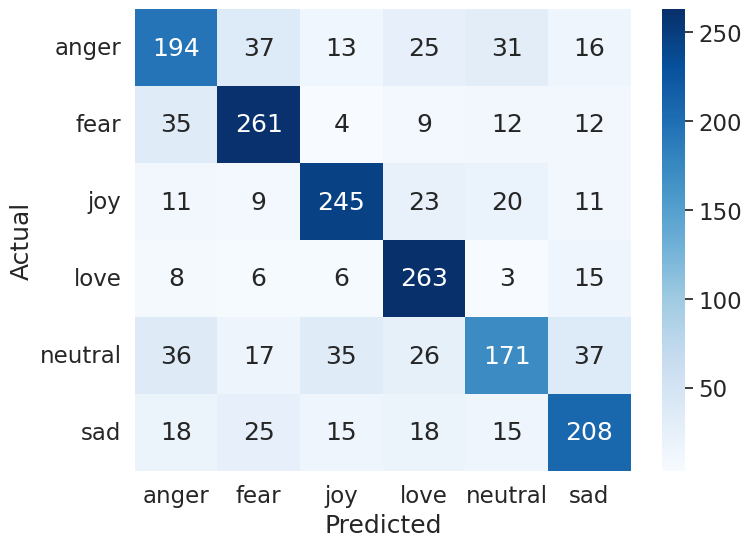

Training finished!


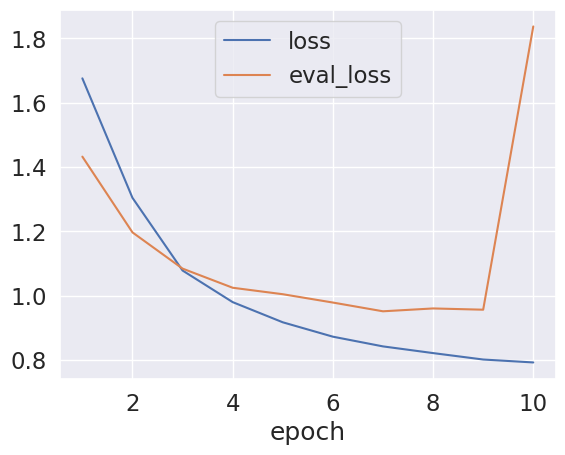

Total time: 9.94285459915797 minutes


In [16]:
#4 google-bert/bert-base-multilingual-cased peft

main(
    model_name = 'google-bert/bert-base-multilingual-cased',
    output_dir = 'p-emotcls-bert-base',
    best_params = 'best_params/p-mbert.json'
)

In [17]:
%cd ..

/content


In [19]:
!zip -r Emotion-classification-with-PEFT_Augmented.zip Emotion-classification-with-PEFT_Augmented/

  adding: Emotion-classification-with-PEFT_Augmented/ (stored 0%)
  adding: Emotion-classification-with-PEFT_Augmented/requirements.txt (deflated 26%)
  adding: Emotion-classification-with-PEFT_Augmented/run_hp_tuning_no_peft.sh (deflated 72%)
  adding: Emotion-classification-with-PEFT_Augmented/hp_tuning_peft.py (deflated 61%)
  adding: Emotion-classification-with-PEFT_Augmented/hp_tuning_no_peft.py (deflated 61%)
  adding: Emotion-classification-with-PEFT_Augmented/p-emotcls-xlm-r-base/ (stored 0%)
  adding: Emotion-classification-with-PEFT_Augmented/p-emotcls-xlm-r-base/special_tokens_map.json (deflated 52%)
  adding: Emotion-classification-with-PEFT_Augmented/p-emotcls-xlm-r-base/checkpoint-828/ (stored 0%)
  adding: Emotion-classification-with-PEFT_Augmented/p-emotcls-xlm-r-base/checkpoint-828/rng_state.pth (deflated 26%)
  adding: Emotion-classification-with-PEFT_Augmented/p-emotcls-xlm-r-base/checkpoint-828/special_tokens_map.json (deflated 52%)
  adding: Emotion-classification-

In [20]:
from google.colab import files
files.download('Emotion-classification-with-PEFT_Augmented.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>